In [222]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
from scipy.stats import norm # for convenient gaussian computation
from sklearn.cluster import KMeans

In [223]:
filename = './data/assignmentSegmentBrainGmmEmMrf.mat'  # Replace with your actual file

with h5py.File(filename, 'r') as f:
    dataset_name = 'imageData'  # Replace with an actual variable name
    imageData = f[dataset_name][:]  # Read dataset into a NumPy array
    dataset_name = 'imageMask'
    imageMask = f[dataset_name][:]

print(imageData) # image intensities
print(imageMask) # pixels within brain = 1, outside brain = 0

y = imageData # consider only pixels within brain
print(y.shape)

[[0.04380123 0.078734   0.05914955 ... 0.02870117 0.04031791 0.01772919]
 [0.0940726  0.0549603  0.09139166 ... 0.04022088 0.0198631  0.02725545]
 [0.00727189 0.01713058 0.01593564 ... 0.05524558 0.01478675 0.04746066]
 ...
 [0.03918136 0.06432267 0.00893907 ... 0.03315672 0.01585535 0.05259117]
 [0.04282553 0.06783914 0.03878266 ... 0.03609456 0.01632443 0.08544449]
 [0.01317979 0.05069654 0.03276115 ... 0.04424991 0.00901131 0.014556  ]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(256, 256)


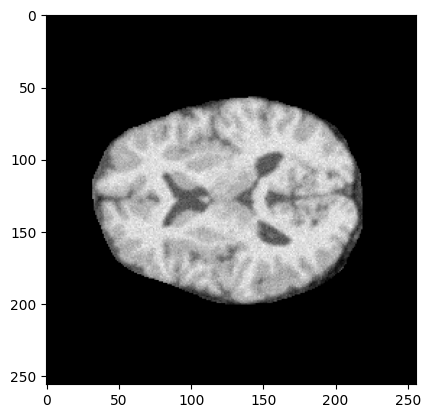

In [258]:
plt.imshow(y * imageMask, cmap = "gray")

In [225]:

K = 3 # num labels
# 1 - White Matter
# 2 - Grey Matter
# 3 - Cerebrospinal Fluid
 
b = 0.5 # beta parameter
a = np.array([1,2,2])
a.shape

(3,)

In [226]:
def initialisation(y, imageMask):

    valid_pixels = y[imageMask > 0].reshape(-1, 1)
    
    kmc = KMeans(n_clusters=3, init="k-means++", random_state=0, n_init=10)
    cluster_labels = kmc.fit_predict(valid_pixels)
    
    # Initialize the full X array
    X = np.zeros_like(y, dtype=int)

    # Map cluster labels back to the original image space
    mask_indices = np.where(imageMask > 0)

    for i, (row, col) in enumerate(zip(mask_indices[0], mask_indices[1])):
        if i < len(cluster_labels):
            X[row, col] = cluster_labels[i]

    # kmc = KMeans(n_clusters=3, init = "k-means++", random_state = 0, n_init = 10) # can outer pixels be avoided?
    # X = kmc.fit_predict(y.reshape(-1, 1)) # MRF label prior
    # X = X.reshape((256, 256))

    classMeans = []
    classStds = []

    for i in range(3):
        cluster = y[X == i]
        classMeans.append(np.mean(cluster))
        classStds.append(np.std(cluster))
    
    return X, classMeans, classStds



In [227]:
def computeMAP(X, y, imageMask, classMeans, classStds, b):
    post = np.zeros((256, 256, 3))

    for i in range (256):
        for j in range(256):

            if (imageMask[i, j] == 0):
                continue
            
            for k in range(3):
                
                likelihood = norm.pdf(y[i, j], classMeans[k], classStds[k])
                prior = 0.0

                for n in  [(1,0), (0,1), (-1,0), (0,-1)]:
                    ni, nj = i + n[0], j + n[1]
                    if 0 <= ni < 256 and 0 <= nj < 256 and imageMask[ni, nj] == 1: 
                        prior += float(b * (X[i, j] != X[ni, nj]))

                post[i, j, k] = likelihood * np.exp(-prior)
    
    X_MAP = np.argmax(post, axis = 2)

    # after_post = 1
    # for i in range (256):
    #     for j in range(256):
    #         if imageMask[i, j] == 1:
    #             after_post *= post[i, j, X_MAP[i, j]]

    log_post = 0
    for i in range(256):
        for j in range(256):
            if imageMask[i, j] == 1:
                k = X_MAP[i, j]
                if post[i, j, k] > 0:
                    log_post += np.log(post[i, j, k])

    return X_MAP, log_post
                    

In [228]:
def optimalMemberships(X_MAP, y, imageMask, classMeans, classStds, b):
    membership = np.zeros((256, 256, 3))
    
    neighbour = [(1,0), (0,1), (-1,0), (0,-1)]

    for i in range(256):
        for j in range(256):

            if (imageMask[i, j] == 0):
                continue

            for k in range (3):

                likelihood = norm.pdf(y[i, j], classMeans[k], classStds[k])  
                prior = 0.0
                for n in neighbour:
                    ni, nj = i + n[0], j + n[1]
                    if 0 <= ni < 256 and 0 <= nj < 256 and imageMask[ni, nj] == 1:        
                        prior += float(b * (k != X_MAP[ni, nj]))

                membership[i, j, k] = likelihood * np.exp(-prior)
    
    for i in range(256):
        for j in range(256):
            if imageMask[i, j] == 1:
                if np.sum(membership[i, j]) > 0:
                    membership[i, j] = membership[i, j] / np.sum(membership[i, j])
    # membership = membership / np.sum(membership, axis = 2, keepdims=True)

    return membership

def optimalClassMeans(y, membership):

    newMeans = np.zeros(3)

    for k in range(3):
        weights_sum = np.sum(membership[:, :, k])
        if weights_sum > 0:
            newMeans[k] = np.sum(y * membership[:, :, k]) / weights_sum
   
    # newMeans = [np.sum(y * membership[:, :, i]) / np.sum(membership[:, :, i]) for i in range(3)]
    return newMeans

def optimalClassStds(y, membership, classMeans):  

    newStds = np.zeros(3)
    
    for k in range(3):
        weights_sum = np.sum(membership[:, :, k])
        if weights_sum > 0:
            newStds[k] = np.sqrt(np.sum(((y - classMeans[k])**2) * membership[:, :, k]) / weights_sum)
        else:
            newStds[k] = 1.0  # Default to 1 if class has no members

    # newStds = [np.sum(((y - classMeans[i])**2) * membership[:, :, i]) / np.sum(membership[:, :, i]) for i in range(3)]
    return newStds


In [229]:
def EM_ICM(y, imageMask, b):
    X, classMeans, classStds = initialisation(y, imageMask)

    # Kmeans used for initial estimate
    print("Initial X estimate")
    # print(np.unique(X))
    print(X) 

    print("Initial Class Means")
    print(classMeans)

    print("Initial Class Standard Deviations")
    print(classStds)

    X_MAP, log_post = computeMAP(X, y, imageMask, classMeans, classStds, b)
    print("Initial log Posterior:", log_post)
    prev_log_post = log_post

    # terminate when labels dont change
    iteration = 0
    converged = 0
    while (not converged): 
        iteration += 1
        print (f"Iteration {iteration}")
        membership = optimalMemberships(X_MAP, y, imageMask, classMeans, classStds, b)
        classMeans = optimalClassMeans(y, membership)
        classStds = optimalClassStds(y, membership, classMeans)
        X = X_MAP.copy()
        X_MAP, log_post = computeMAP(X, y, imageMask, classMeans, classStds, b)
        print(f"Log Posterior: {log_post}")

        if log_post < prev_log_post:
            converged = 1
        else:
            prev_log_post = log_post

    print("Optimal Estimate for Class Means")
    print(classMeans)

    return membership, X, prev_log_post, classMeans

In [ ]:
# # To find optimal Beta(b) value - manual Binary Search and found optimal value based on final posterior value
# # max_final = 0
# # optimal_b = -1
# label_images = []
# for b in np.arange(0, 10, 0.5):

#     membership, X, final_log_post, classMeans = EM_ICM(y, imageMask, b)
#     label_images.append(X)
#     # plt.imshow(X)
#     # if final_log_post > max_final:
#     #     optimal_b = b
#     #     max_final = final_log_post
#     #     optimalMeans = classMeans

Initial X estimate
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Initial Class Means
[0.17841426347889974, 0.5050471816858487, 0.26990758442032775]
Initial Class Standard Deviations
[0.2289962219763775, 0.04419267701147453, 0.0773977881149821]
Initial log Posterior: 11555.34460013767
Iteration 1
Log Posterior: 27421.453562889717
Iteration 2
Log Posterior: 28364.389611689523
Iteration 3
Log Posterior: 28105.324480131792
Optimal Estimate for Class Means
[0.57941947 0.5680691  0.30938675]
Initial X estimate
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Initial Class Means
[0.17841426347889974, 0.5050471816858487, 0.26990758442032775]
Initial Class Standard Deviations
[0.2289962219763775, 0.04419267701147453, 0.0773977881149821]
Initial log Posterior: 3772.3446001376587
Iteration 1
Log Posterior: 19394.3021217004
Iteration 2
Log Posterior: 2314

KeyboardInterrupt: 

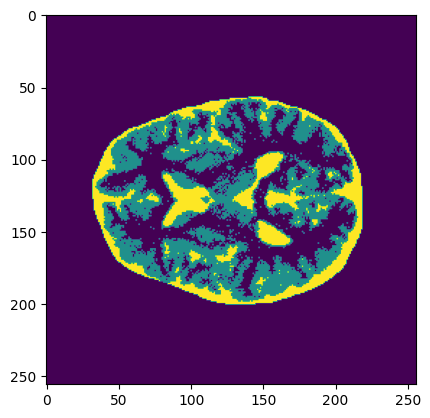

In [ ]:
# for X in label_images:
#     plt.imshow(X)

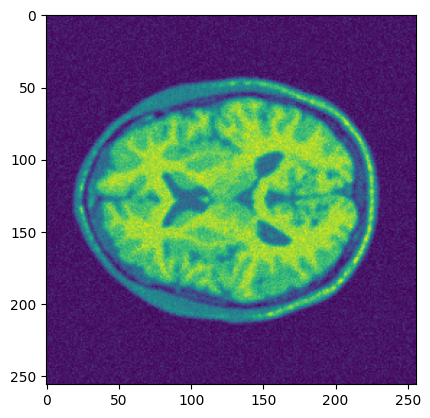

In [256]:
# Corrupted image provided
plt.imshow(imageData)

Chosen b: 5
Initial X estimate
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Initial Class Means
[0.17841426347889974, 0.5050471816858487, 0.26990758442032775]
Initial Class Standard Deviations
[0.2289962219763775, 0.04419267701147453, 0.0773977881149821]
Initial log Posterior: -66274.65539986284
Iteration 1
Log Posterior: -58926.862827932746
Iteration 2
Log Posterior: -44716.62062510491
Iteration 3
Log Posterior: -40660.33627111793
Iteration 4
Log Posterior: -40693.26608337808
Optimal Estimate for Class Means
[0.63482769 0.52730296 0.30029776]
Optimal class-membership image estimates for chosen b


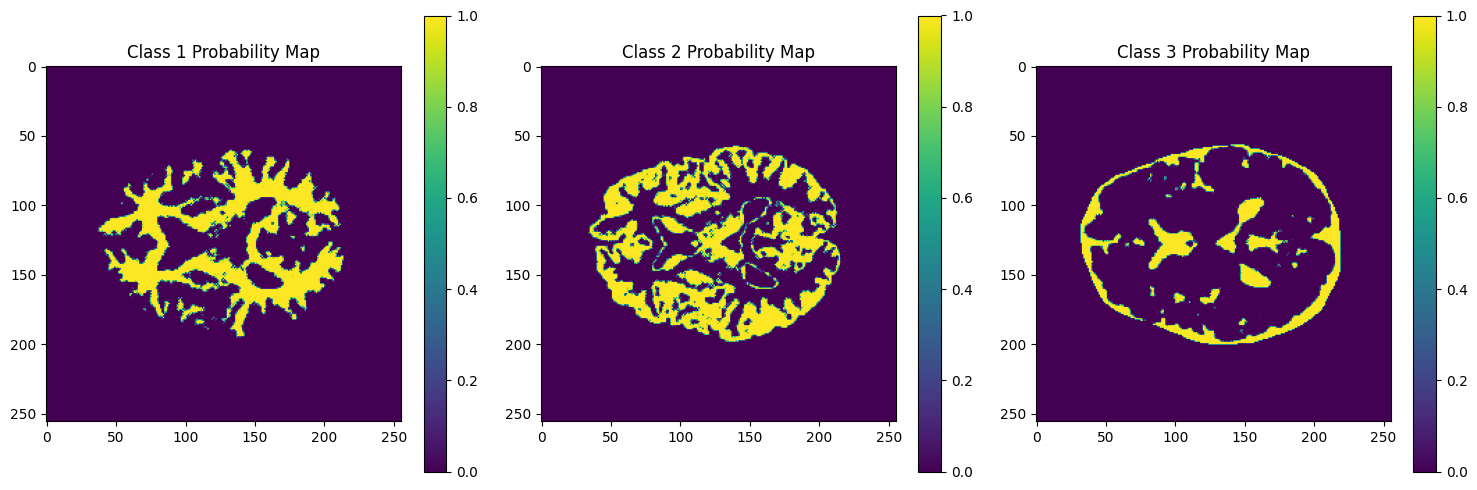

Optimal label image estimate for chosen b
Optimal estimates for the class means for the chosen B
[0.63482769 0.52730296 0.30029776]


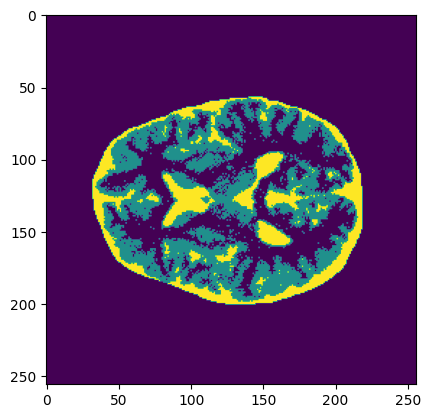

In [268]:
b = 5 # optimal value based on label image displays on posterior value
print("Chosen b:", b)
membership5, X5, log_post5, means5 = EM_ICM(y, imageMask, b=5)
# Optimal class-membership image estimates for chosen b
print("Optimal class-membership image estimates for chosen b")
# print(membership)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for k in range(3):
    im = axes[k].imshow(membership5[:, :, k], cmap='viridis')
    axes[k].set_title(f'Class {k+1} Probability Map')
    fig.colorbar(im, ax=axes[k])
plt.tight_layout()
plt.show()
# Optimal label image estimate for chosen b
print("Optimal label image estimate for chosen b")
plt.imshow(X5)

# optimal estimates for the class means for the chosen
print("Optimal estimates for the class means for the chosen B")
print(means5)

Initial X estimate
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Initial Class Means
[0.17841426347889974, 0.5050471816858487, 0.26990758442032775]
Initial Class Standard Deviations
[0.2289962219763775, 0.04419267701147453, 0.0773977881149821]
Initial log Posterior: 11555.34460013767
Iteration 1
Log Posterior: 27421.453562889717
Iteration 2
Log Posterior: 28364.389611689523
Iteration 3
Log Posterior: 28105.324480131792
Optimal Estimate for Class Means
[0.57941947 0.5680691  0.30938675]
Optimal class-membership image estimates for b = 0


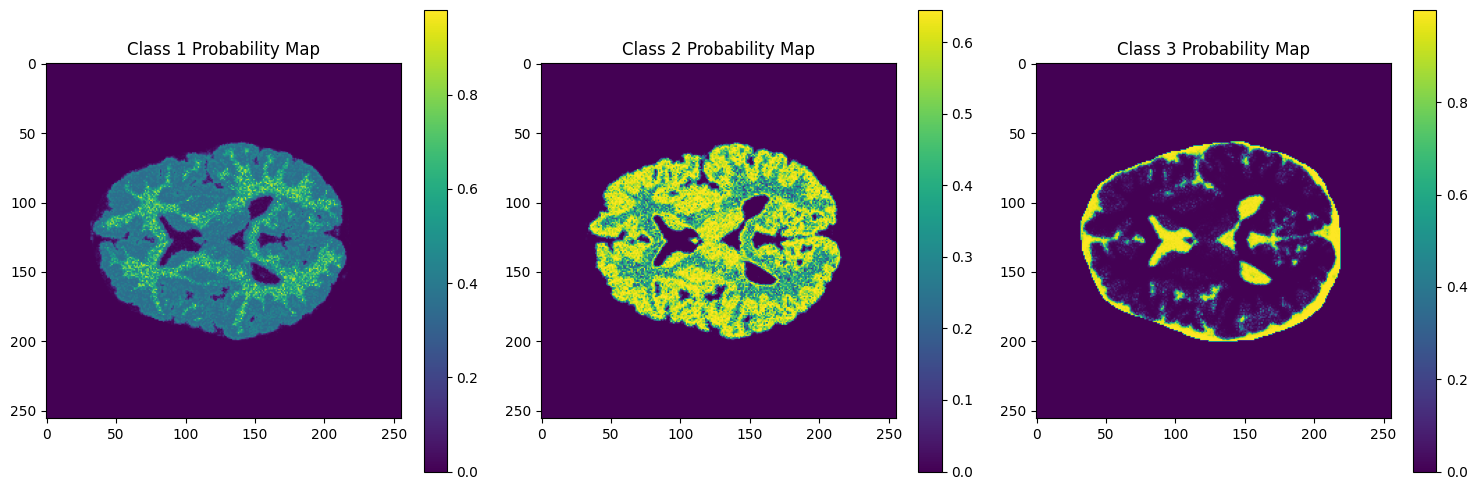

Optimal label image estimate for for b = 0


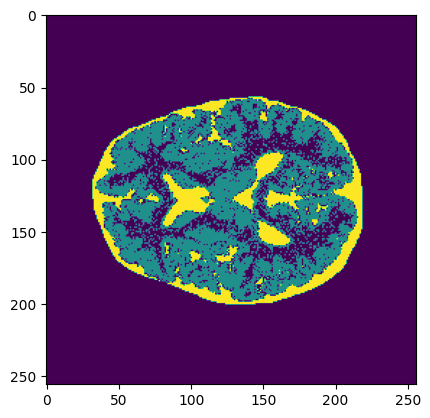

In [267]:
membership0, X0, log_post0, means0 = EM_ICM(y, imageMask, b=0)
# Optimal class-membership image estimates for b = 0
print("Optimal class-membership image estimates for b = 0")
# print(membership0)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for k in range(3):
    im = axes[k].imshow(membership0[:, :, k], cmap='viridis')
    axes[k].set_title(f'Class {k+1} Probability Map')
    fig.colorbar(im, ax=axes[k])
plt.tight_layout()
plt.show()
# Optimal label image estimate for for b = 0
print("Optimal label image estimate for for b = 0")
plt.imshow(X0)